# 02b. Processed Buildings & BBR↔DAR Linking

This notebook explores the **processed** building data and investigates how BBR building attributes
can be linked to DAR entrance points.

**Data Sources:**
- **Buildings (BBR)**: `data/processed/norrebro_buildings.gpkg` layer `buildings` — 3,439 buildings with use codes, construction years, materials.
- **Entrances (DAR)**: `data/processed/norrebro_buildings.gpkg` layer `entrances` — 5,643 accurate entrance points (TD/TK only).
- **Footprints**: `data/processed/norrebro_building_footprints.gpkg` — INSPIRE polygon geometries.
- **Boundary**: `data/processed/norrebro_boundary.gpkg`.

**Goals:**
1. **Use & Era**: Visualize building use categories and construction eras from the processed data.
2. **Entrances**: Map DAR entrance points against building footprints.
3. **BBR↔DAR Linking**: Investigate spatial join and UUID-based strategies for connecting buildings to entrances.

In [1]:
import sys
from pathlib import Path

project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import geopandas as gpd
from src.visualization import style
import contextily as ctx

style.apply_style()

## 1. Load Processed Data

In [2]:
data_dir = project_root / "data" / "processed"

gdf_buildings = gpd.read_file(data_dir / "norrebro_buildings.gpkg", layer="buildings")
gdf_entrances = gpd.read_file(data_dir / "norrebro_buildings.gpkg", layer="entrances")
gdf_footprints = gpd.read_file(data_dir / "norrebro_building_footprints.gpkg")
gdf_boundary = gpd.read_file(
    data_dir / "norrebro_boundary.gpkg", layer="norrebro_boundary"
)

print(f"BBR Buildings: {len(gdf_buildings)}")
print(f"DAR Entrances: {len(gdf_entrances)}")
print(f"INSPIRE Footprints: {len(gdf_footprints)}")
print(f"\nBuilding columns: {list(gdf_buildings.columns)}")
print(f"Entrance columns: {list(gdf_entrances.columns)}")

BBR Buildings: 3439
DAR Entrances: 5643
INSPIRE Footprints: 5914

Building columns: ['building_id', 'building_number', 'use_code', 'construction_year', 'floors', 'total_area_m2', 'residential_area_m2', 'commercial_area_m2', 'footprint_area_m2', 'wall_material', 'roof_material', 'heating_type', 'husnummer_id', 'municipality_code', 'use_description', 'use_category', 'construction_era', 'geometry']
Entrance columns: ['entrance_id', 'positioning_type', 'status', 'geometry']


## 2. Building Use Overview
Distribution of buildings by use category and the top specific use descriptions.

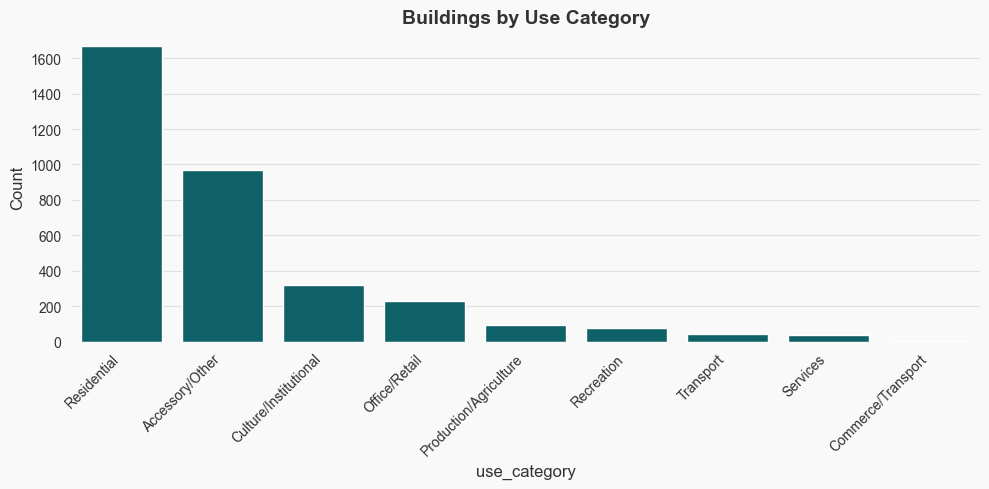

In [3]:
# Use category distribution
cat_counts = gdf_buildings["use_category"].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=cat_counts.index, y=cat_counts.values, color=style.PALETTE["brand"])
plt.title("Buildings by Use Category")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Count")
sns.despine()
plt.tight_layout()
plt.show()

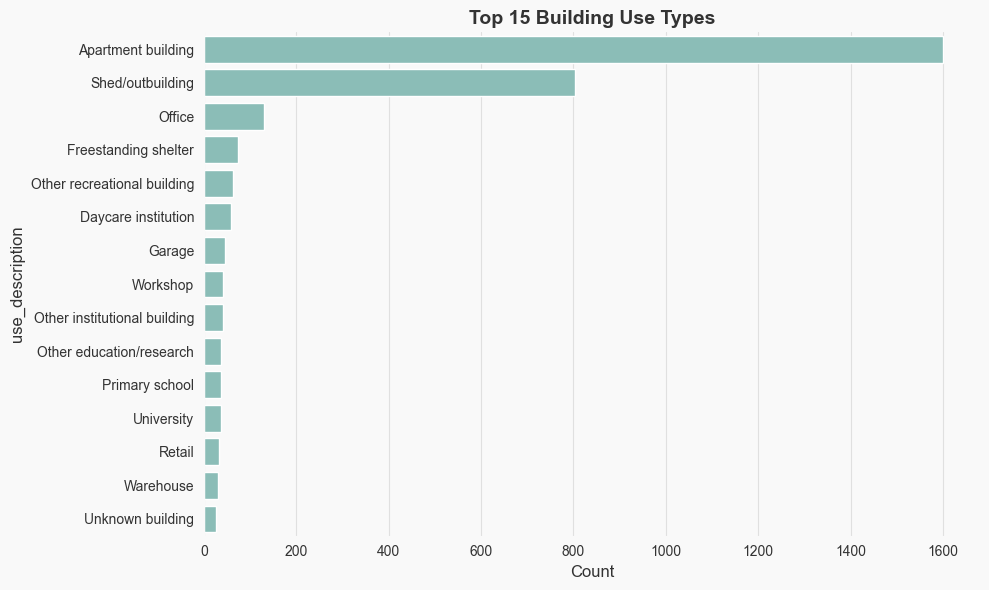

In [4]:
# Top 15 specific use descriptions
desc_counts = gdf_buildings["use_description"].value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=desc_counts.values, y=desc_counts.index, color=style.PALETTE["brand_light"]
)
plt.title("Top 15 Building Use Types")
plt.xlabel("Count")
sns.despine()
plt.tight_layout()
plt.show()

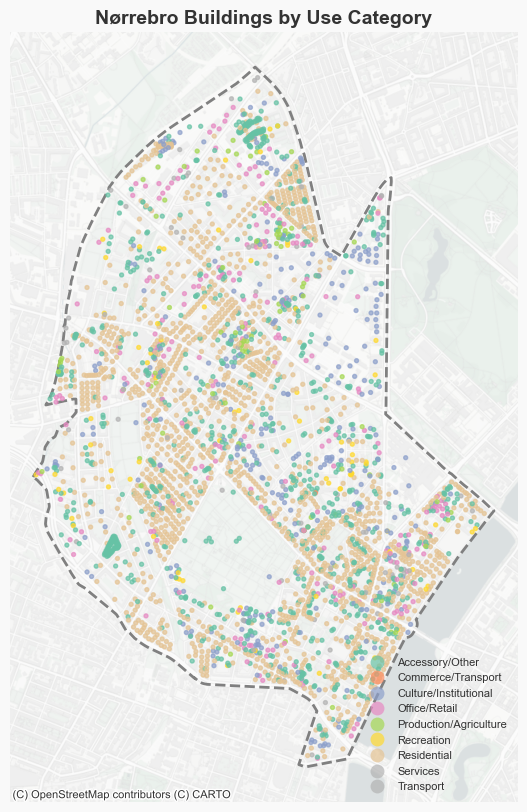

In [5]:
# Map: buildings coloured by use category
fig, ax = plt.subplots(figsize=(12, 10))

gdf_boundary.plot(
    ax=ax, facecolor="none", edgecolor="grey", linestyle="--", linewidth=2
)

gdf_buildings.plot(
    ax=ax,
    column="use_category",
    cmap="Set2",
    legend=True,
    markersize=8,
    alpha=0.7,
    legend_kwds={"loc": "lower right", "fontsize": 8},
)

ctx.add_basemap(
    ax, source=ctx.providers.CartoDB.PositronNoLabels, crs="EPSG:25832", alpha=0.8
)
ax.set_title("N\u00f8rrebro Buildings by Use Category")
ax.set_axis_off()
plt.show()

## 3. Construction Timeline
Distribution of buildings by construction era, reflecting N\u00f8rrebro's historical development waves.

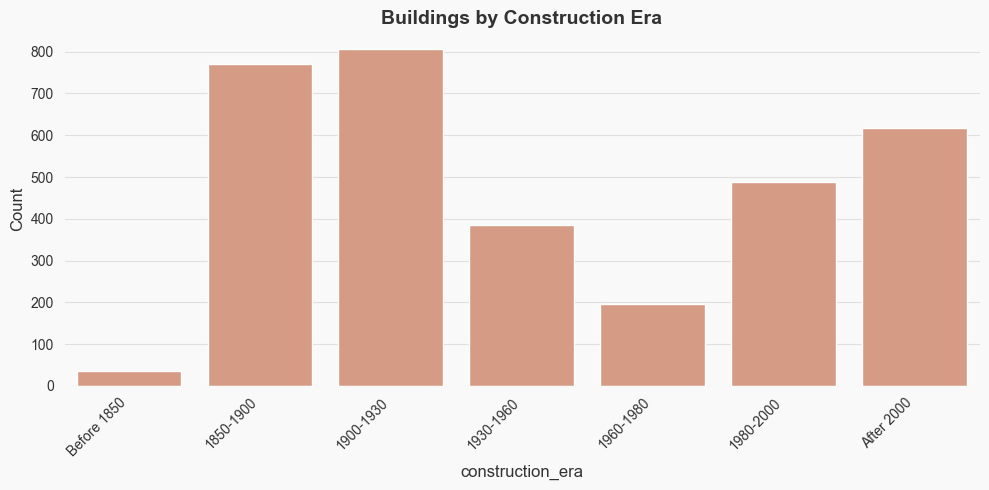

In [6]:
# Construction era distribution (ordered)
era_order = [
    "Before 1850",
    "1850-1900",
    "1900-1930",
    "1930-1960",
    "1960-1980",
    "1980-2000",
    "After 2000",
]
era_counts = (
    gdf_buildings["construction_era"].value_counts().reindex(era_order).dropna()
)

plt.figure(figsize=(10, 5))
sns.barplot(x=era_counts.index, y=era_counts.values, color=style.PALETTE["accent_warm"])
plt.title("Buildings by Construction Era")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
sns.despine()
plt.tight_layout()
plt.show()

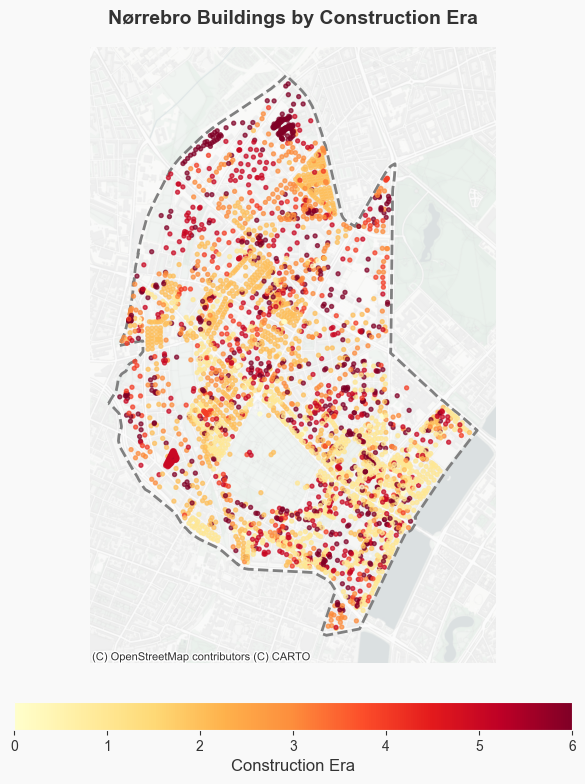

In [7]:
# Map: buildings coloured by construction era
fig, ax = plt.subplots(figsize=(12, 10))

gdf_boundary.plot(
    ax=ax, facecolor="none", edgecolor="grey", linestyle="--", linewidth=2
)

# Map era to numeric for sequential colormap
era_to_num = {era: i for i, era in enumerate(era_order)}
gdf_buildings["era_num"] = gdf_buildings["construction_era"].map(era_to_num)

gdf_buildings.dropna(subset=["era_num"]).plot(
    ax=ax,
    column="era_num",
    cmap="YlOrRd",
    legend=True,
    markersize=8,
    alpha=0.7,
    legend_kwds={
        "label": "Construction Era",
        "orientation": "horizontal",
        "shrink": 0.6,
        "pad": 0.05,
    },
)

ctx.add_basemap(
    ax, source=ctx.providers.CartoDB.PositronNoLabels, crs="EPSG:25832", alpha=0.8
)
ax.set_title("N\u00f8rrebro Buildings by Construction Era")
ax.set_axis_off()
plt.show()

## 4. Entrances Overview
DAR entrance points (TD = building door, TK = building facade) overlaid on building footprints.

In [8]:
print("Entrance positioning types:")
print(gdf_entrances["positioning_type"].value_counts())
print(f"\nTotal: {len(gdf_entrances)} entrances")

Entrance positioning types:
positioning_type
TD    5639
TK       4
Name: count, dtype: int64

Total: 5643 entrances


/var/folders/j6/ft69qsf979gflgtqf862qt000000gs/T/ipykernel_68790/1391807971.py:26: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="upper right")


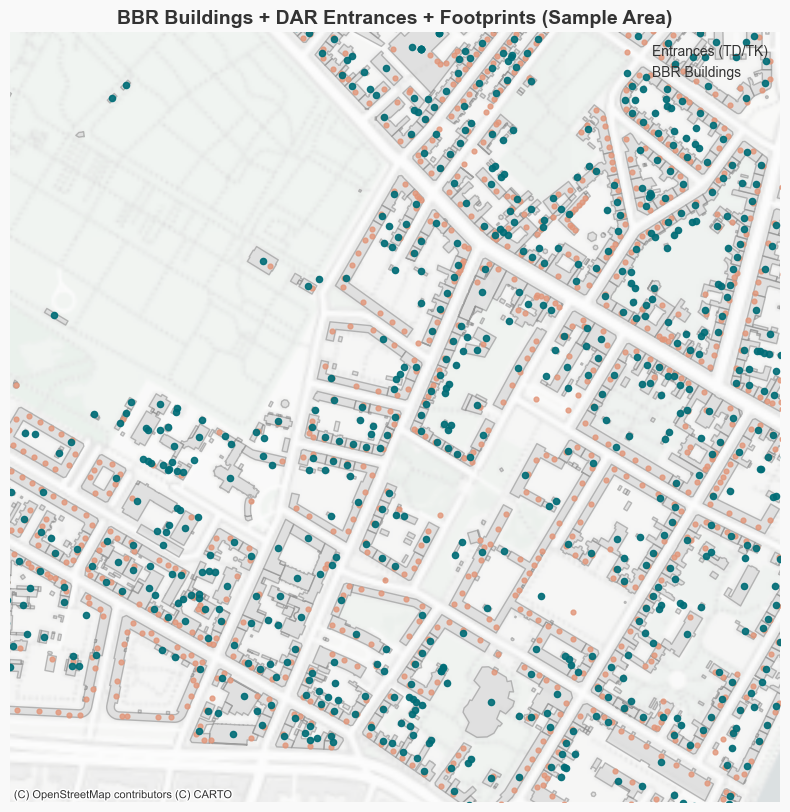

In [9]:
# Zoom to a sample area: centre of N\u00f8rrebro (around Bl\u00e5g\u00e5rds Plads)
sample_center = gdf_buildings.geometry.iloc[100]
sample_buf = sample_center.buffer(400)
xlim = (sample_buf.bounds[0], sample_buf.bounds[2])
ylim = (sample_buf.bounds[1], sample_buf.bounds[3])

fig, ax = plt.subplots(figsize=(10, 10))

# Footprints
gdf_footprints.plot(
    ax=ax, color="lightgrey", edgecolor="grey", alpha=0.5, label="Footprints"
)

# Entrances
gdf_entrances.plot(
    ax=ax,
    color=style.PALETTE["accent_warm"],
    markersize=12,
    alpha=0.8,
    label="Entrances (TD/TK)",
)

# BBR points
gdf_buildings.plot(
    ax=ax,
    color=style.PALETTE["brand"],
    markersize=20,
    alpha=0.9,
    label="BBR Buildings",
    zorder=3,
)

ctx.add_basemap(
    ax, source=ctx.providers.CartoDB.PositronNoLabels, crs="EPSG:25832", alpha=0.8
)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_title("BBR Buildings + DAR Entrances + Footprints (Sample Area)")
ax.legend(loc="upper right")
ax.set_axis_off()
plt.show()

## 5. BBR↔DAR Linking Investigation

How can we connect BBR building attributes to DAR entrance points?

**Two approaches:**
1. **Spatial join** via INSPIRE footprint polygons (BBR point → footprint polygon ← DAR point)
2. **UUID linking** via `husnummer_id` (BBR → Husnummer entity → DAR) — requires downloading the Husnummer file (~620 MB)

### 5.1 Spatial Join: BBR → Footprints
How many BBR building points fall inside an INSPIRE footprint polygon?

In [10]:
# Spatial join: BBR points within footprint polygons
bbr_in_fp = gpd.sjoin(gdf_buildings, gdf_footprints, predicate="within", how="left")

matched = bbr_in_fp["index_right"].notna().sum()
total = len(gdf_buildings)
print(
    f"BBR buildings matched to a footprint: {matched} / {total} ({matched / total:.1%})"
)
print(f"Unmatched: {total - matched}")

BBR buildings matched to a footprint: 3157 / 3439 (91.8%)
Unmatched: 282


### 5.2 Spatial Join: DAR Entrances → Footprints
How many entrance points fall inside a footprint polygon?

Note: TD points are at the building door, so some may be at the boundary/outside the polygon.

In [11]:
# Spatial join: DAR entrances within footprint polygons
dar_in_fp = gpd.sjoin(gdf_entrances, gdf_footprints, predicate="within", how="left")

matched_dar = dar_in_fp["index_right"].notna().sum()
total_dar = len(gdf_entrances)
print(
    f"Entrances matched to a footprint: {matched_dar} / {total_dar} ({matched_dar / total_dar:.1%})"
)
print(f"Unmatched: {total_dar - matched_dar}")
print()
print("Entrances are at the door, so some fall just outside the polygon.")
print("Try with a small buffer (2m) on the footprints for better matching:")

# Buffer footprints by 2m for better entrance matching
fp_buffered = gdf_footprints.copy()
fp_buffered["geometry"] = fp_buffered.geometry.buffer(2)
dar_in_fp_buf = gpd.sjoin(gdf_entrances, fp_buffered, predicate="within", how="left")

matched_buf = dar_in_fp_buf["index_right"].notna().sum()
print(f"With 2m buffer: {matched_buf} / {total_dar} ({matched_buf / total_dar:.1%})")

Entrances matched to a footprint: 5514 / 5643 (97.7%)
Unmatched: 129

Entrances are at the door, so some fall just outside the polygon.
Try with a small buffer (2m) on the footprints for better matching:
With 2m buffer: 5618 / 5643 (99.6%)


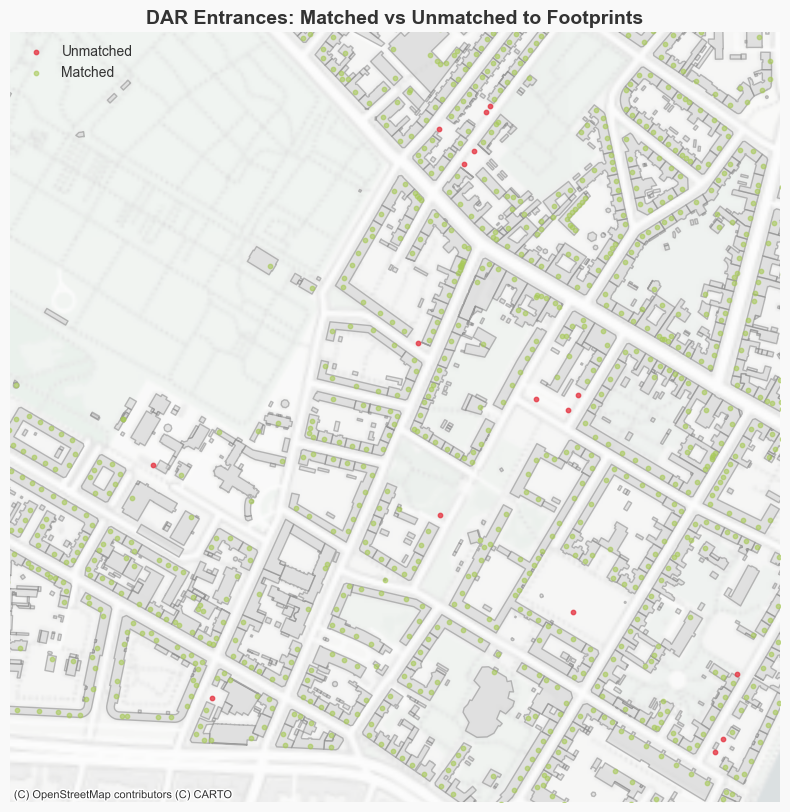

In [12]:
# Visualize matched vs unmatched entrances in the sample area
dar_in_fp["matched"] = dar_in_fp["index_right"].notna()

fig, ax = plt.subplots(figsize=(10, 10))

gdf_footprints.plot(ax=ax, color="lightgrey", edgecolor="grey", alpha=0.5)

# Unmatched (red) first, then matched (green) on top
dar_in_fp[~dar_in_fp["matched"]].plot(
    ax=ax, color="#E63946", markersize=10, alpha=0.8, label="Unmatched"
)
dar_in_fp[dar_in_fp["matched"]].plot(
    ax=ax, color=style.PALETTE["park"], markersize=10, alpha=0.6, label="Matched"
)

ctx.add_basemap(
    ax, source=ctx.providers.CartoDB.PositronNoLabels, crs="EPSG:25832", alpha=0.8
)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_title("DAR Entrances: Matched vs Unmatched to Footprints")
ax.legend()
ax.set_axis_off()
plt.show()

### 5.3 UUID Linking Feasibility
BBR buildings have a `husnummer_id` field (UUID) that links to the national Husnummer register.
The chain is: **BBR.husnummer_id → Husnummer entity → DAR.adressepunkt**.

The Husnummer file (~620 MB) has not been downloaded yet. Let's assess the feasibility.

In [13]:
# Check husnummer_id availability in BBR
has_husnummer = gdf_buildings["husnummer_id"].notna().sum()
total_bbr = len(gdf_buildings)
print(
    f"Buildings with husnummer_id: {has_husnummer} / {total_bbr} ({has_husnummer / total_bbr:.1%})"
)
print(f"Buildings without husnummer_id: {total_bbr - has_husnummer}")
print()

# Check uniqueness
n_unique = gdf_buildings["husnummer_id"].nunique()
print(f"Unique husnummer_id values: {n_unique}")
print(
    f"Ratio (unique / non-null): {n_unique / has_husnummer:.2f}"
    if has_husnummer > 0
    else "N/A"
)
print()

# How many buildings share the same husnummer_id?
if has_husnummer > 0:
    hn_counts = gdf_buildings["husnummer_id"].value_counts()
    print("husnummer_id sharing distribution:")
    print(f"  1 building per husnummer: {(hn_counts == 1).sum()}")
    print(f"  2+ buildings per husnummer: {(hn_counts > 1).sum()}")
    if (hn_counts > 1).any():
        print(f"  Max buildings sharing one husnummer: {hn_counts.max()}")

Buildings with husnummer_id: 3437 / 3439 (99.9%)
Buildings without husnummer_id: 2

Unique husnummer_id values: 2272
Ratio (unique / non-null): 0.66

husnummer_id sharing distribution:
  1 building per husnummer: 1706
  2+ buildings per husnummer: 566
  Max buildings sharing one husnummer: 54


### 5.4 One-to-Many: Entrances per Footprint
A single building (especially apartment blocks, code 140) likely has multiple entrance points.
Count entrances per footprint to understand this relationship.

In [14]:
# Count entrances per footprint (using 2m buffered footprints for better matching)
fp_with_counts = fp_buffered.copy()
fp_with_counts["geometry"] = (
    gdf_footprints.geometry
)  # restore original geometry for plotting

# Count entrances in each buffered footprint
entrance_counts = dar_in_fp_buf.groupby("index_right").size().rename("entrance_count")
fp_with_counts = fp_with_counts.join(entrance_counts)
fp_with_counts["entrance_count"] = (
    fp_with_counts["entrance_count"].fillna(0).astype(int)
)

print("Entrances per footprint:")
print(fp_with_counts["entrance_count"].describe())
print()

has_entrances = fp_with_counts["entrance_count"] > 0
print(
    f"Footprints with at least 1 entrance: {has_entrances.sum()} / {len(fp_with_counts)}"
)
print(f"Footprints with 5+ entrances: {(fp_with_counts['entrance_count'] >= 5).sum()}")
print(
    f"Footprints with 10+ entrances: {(fp_with_counts['entrance_count'] >= 10).sum()}"
)

Entrances per footprint:
count    5914.000000
mean        0.949949
std         2.175350
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max        31.000000
Name: entrance_count, dtype: float64

Footprints with at least 1 entrance: 2149 / 5914
Footprints with 5+ entrances: 250
Footprints with 10+ entrances: 76


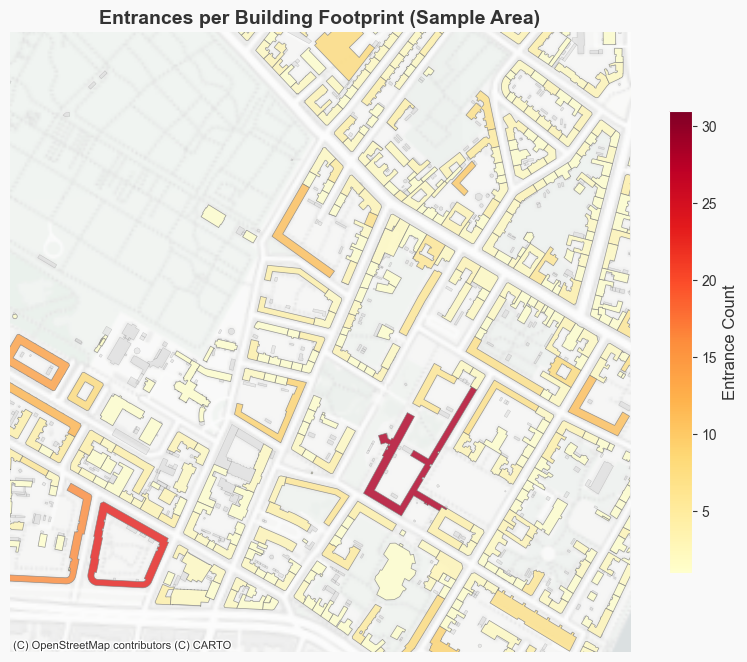

In [15]:
# Choropleth: entrances per footprint (sample area)
fig, ax = plt.subplots(figsize=(10, 10))

fp_with_counts[fp_with_counts["entrance_count"] > 0].plot(
    ax=ax,
    column="entrance_count",
    cmap="YlOrRd",
    legend=True,
    edgecolor="grey",
    linewidth=0.5,
    alpha=0.8,
    legend_kwds={"label": "Entrance Count", "shrink": 0.6},
)

# Footprints without entrances in light grey
fp_with_counts[fp_with_counts["entrance_count"] == 0].plot(
    ax=ax, color="lightgrey", edgecolor="grey", linewidth=0.3, alpha=0.4
)

ctx.add_basemap(
    ax, source=ctx.providers.CartoDB.PositronNoLabels, crs="EPSG:25832", alpha=0.8
)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_title("Entrances per Building Footprint (Sample Area)")
ax.set_axis_off()
plt.show()

### 5.5 Conclusions: Linking Strategy

**Spatial join** (BBR/DAR points → INSPIRE footprint polygons):
- Works well for BBR (points tend to be inside footprints)
- For DAR entrances, a small buffer (~2m) on footprints improves matching since TD points are at the door
- This approach is available now and doesn’t require additional data downloads

**UUID linking** (BBR.husnummer_id → Husnummer → DAR):
- Requires downloading the national Husnummer file (~620 MB) from Datafordeleren
- Would provide an exact, non-spatial link between buildings and addresses
- Useful for cases where spatial join fails (e.g., buildings without footprints)

**Recommendation**: Use spatial join via footprints as the primary linking method. Download the Husnummer file only if exact address-level linking is needed later.